Loading Experiment ID: 1...
⚠️ Filtered out 126 rows exceeding 500 tokens (Context Cutoff Safety). Remaining: 3874


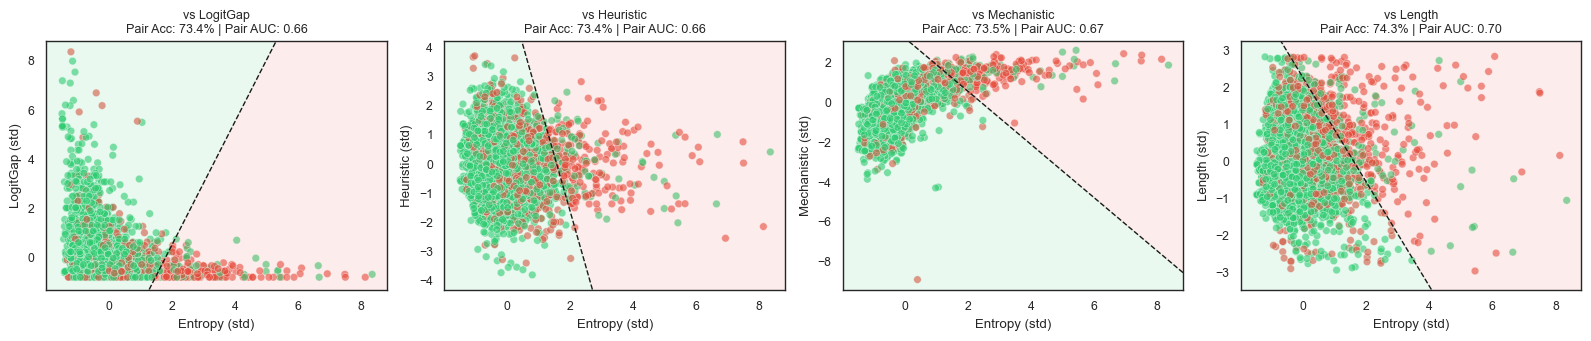

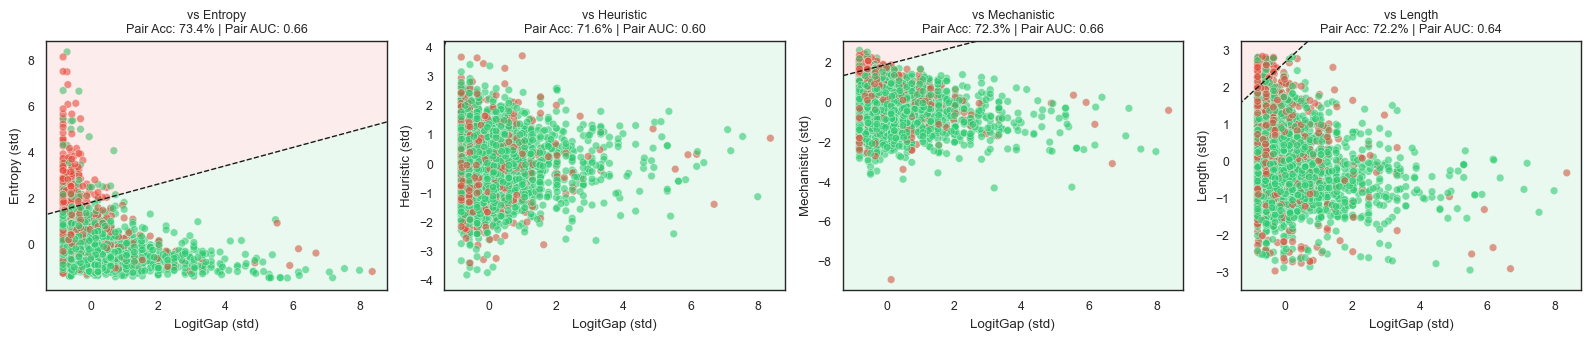

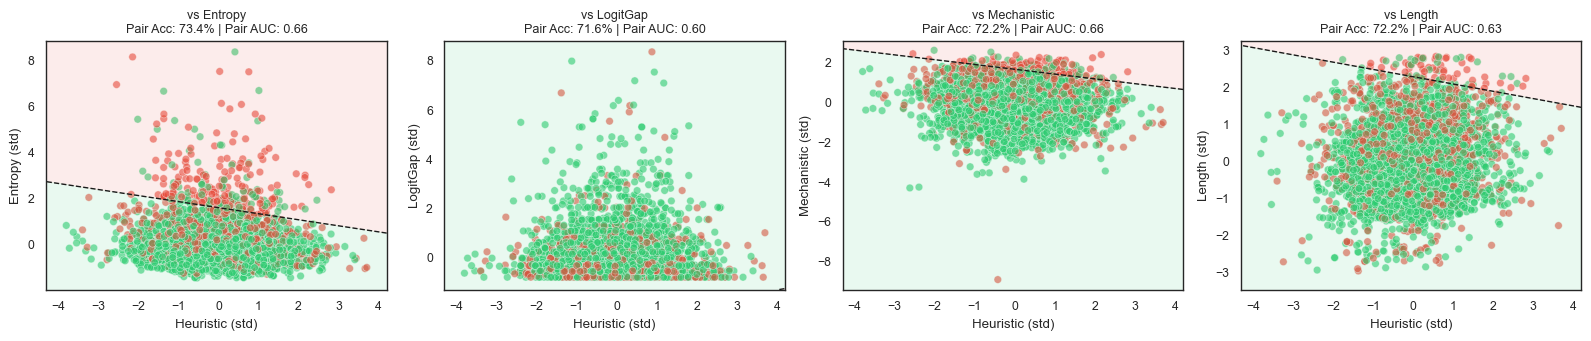

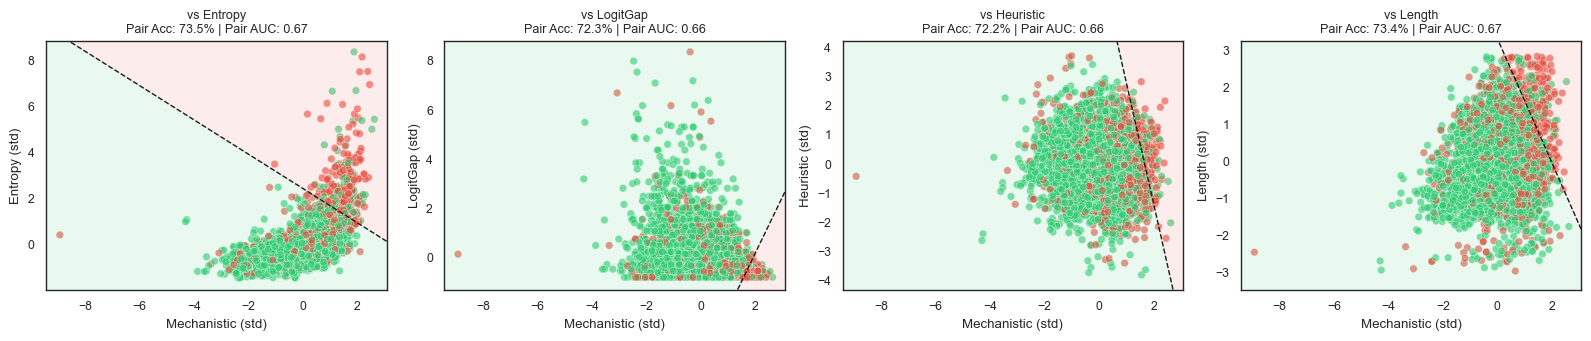

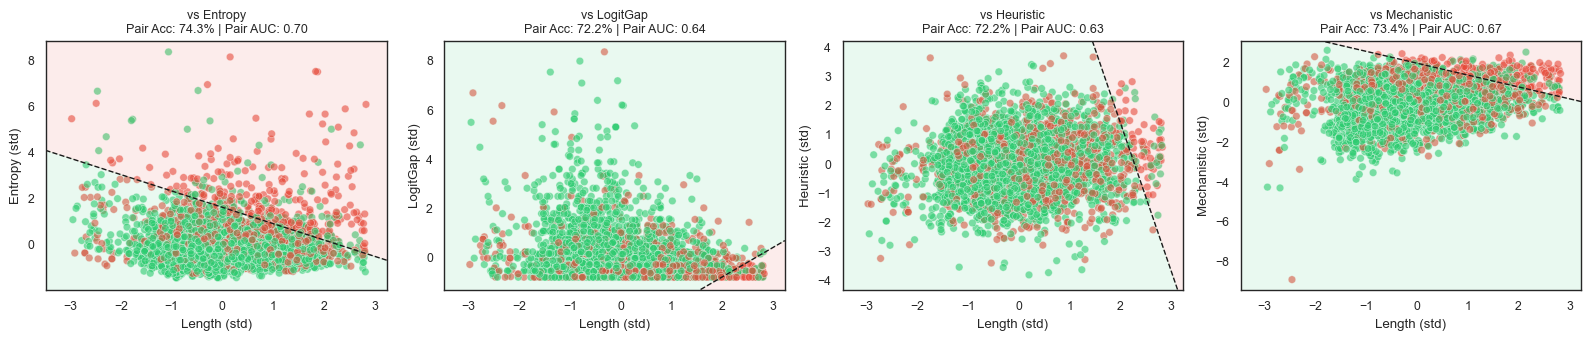

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from IPython.display import display, HTML
import os

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite"
sns.set_theme(style="white", context="paper")
warnings.filterwarnings('ignore')

# --- 1. DATA LOADING & PREPROCESSING ---
def load_comprehensive_data(db_path):
    if not os.path.exists(db_path):
        print(f"❌ Database not found at {db_path}")
        return None, None

    conn = sqlite3.connect(db_path)
    try:
        exp_id = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY experiment_id DESC LIMIT 1", conn).iloc[0,0]
    except:
        print("❌ No experiments found.")
        return None, None

    print(f"Loading Experiment ID: {exp_id}...")
    query = f"""
    SELECT 
        r.result_id, r.is_correct, r.predicted_answer,
        r.uq_avg_entropy as 'Entropy',
        r.uq_min_logit_gap as 'LogitGap',
        r.uq_heuristic_score as 'Heuristic', 
        r.uq_mech_score as 'Mechanistic',
        r.uq_tokens, r.uq_mech_trace, r.uq_entropy_trace, r.uq_logit_gap_trace
    FROM Results r 
    WHERE r.experiment_id = {exp_id}
    """
    df = pd.read_sql(query, conn)
    conn.close()

    # Preprocess
    df['is_correct'] = df['is_correct'].astype(int)
    
    # Parse JSON Traces
    for col in ['uq_tokens', 'uq_mech_trace', 'uq_entropy_trace', 'uq_logit_gap_trace']:
        df[col] = df[col].apply(lambda x: json.loads(x) if x else [])

    # --- ADD LENGTH & FILTER ---
    df['Length'] = df['uq_tokens'].apply(len)
    
    # FILTER: Drop Cutoff Failures (> 500 Tokens)
    initial_count = len(df)
    df = df[df['Length'] <= 500]
    dropped_count = initial_count - len(df)
    if dropped_count > 0:
        print(f"⚠️ Filtered out {dropped_count} rows exceeding 500 tokens (Context Cutoff Safety). Remaining: {len(df)}")
    else:
        print("✅ No rows exceeded 500 tokens.")

    # Standardize Metrics (Z-Score)
    metrics = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    for m in metrics:
        if df[m].std() == 0: df[f'{m}_Z'] = 0
        else: df[f'{m}_Z'] = (df[m] - df[m].mean()) / df[m].std()
        
    return df, metrics

# --- 2. VISUALIZATION HELPERS ---
def generate_token_html(tokens, values, metric_name):
    """Generates HTML with token-level coloring."""
    if not tokens: return "No Trace Data"
    
    # Handle mismatches
    if not values or len(values) < len(tokens):
        vals = np.zeros(len(tokens))
    else:
        vals = np.array(values[:len(tokens)])

    if len(vals) == 0: return ""
    v_min, v_max = vals.min(), vals.max()
    
    html_parts = []
    for t, v in zip(tokens, vals):
        if v_max - v_min == 0: norm = 0.5
        else: norm = (v - v_min) / (v_max - v_min)
        
        hue = 120 * norm 
        color = f"hsl({hue}, 80%, 85%)"
        t_clean = str(t).replace('Ġ', ' ').replace('Ċ', '↵').replace('<', '&lt;').replace('>', '&gt;')
        html_parts.append(f"<span style='background-color:{color}; padding:0 2px; border-radius:2px;' title='{v:.4f}'>{t_clean}</span>")
    
    return "".join(html_parts)

def plot_decision_boundary(ax, df, x_col, y_col, target):
    """Plots scatter and LR decision boundary."""
    X = df[[x_col, y_col]].values
    y = df[target].values
    
    if len(np.unique(y)) < 2: return # Skip if only 1 class exists
    
    # Scatter
    sns.scatterplot(
        data=df, x=x_col, y=y_col, hue=target, 
        palette={0: '#e74c3c', 1: '#2ecc71'}, 
        alpha=0.6, s=30, ax=ax, legend=False
    )
    
    # Pairwise Classifier
    clf = LogisticRegression()
    clf.fit(X, y)
    acc = accuracy_score(y, clf.predict(X))
    try: auc = roc_auc_score(y, clf.predict_proba(X)[:,1])
    except: auc = 0.5
    
    # Contours
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--', linewidths=1)
    ax.contourf(xx, yy, Z, levels=[0.0, 0.5, 1.0], colors=['#e74c3c', '#2ecc71'], alpha=0.1)
    
    ax.set_title(f"vs {y_col.split('_')[0]}\nPair Acc: {acc:.1%} | Pair AUC: {auc:.2f}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# --- 3. MAIN ANALYSIS LOOP ---
df, metrics = load_comprehensive_data(DB_PATH)

if df is not None and len(df) > 10:
    for m_exam in metrics:
        # --- A. INDIVIDUAL METRIC STATS ---
        try:
            auroc_single = roc_auc_score(1 - df['is_correct'], df[m_exam])
        except:
            auroc_single = 0.5
            
        clf_single = LogisticRegression()
        clf_single.fit(df[[f'{m_exam}_Z']], df['is_correct'])
        acc_single = accuracy_score(df['is_correct'], clf_single.predict(df[[f'{m_exam}_Z']]))

        # Header
        header_html = f"""
        <div style='border-bottom:3px solid #3498db; padding-top:20px; margin-bottom:15px'>
            <div style='display:flex; justify-content:space-between; align-items:center'>
                <h2 style='margin:0; color:#2c3e50'>{m_exam} Analysis</h2>
                <div style='font-family:sans-serif; font-size:0.95em;'>
                    <span style='color:#7f8c8d'>Individual Power (Error Detection):</span> 
                    <span style='background:#f1f2f6; padding:4px 8px; border-radius:4px; font-weight:bold; color:#2c3e50; border:1px solid #ccc'>
                        AUROC: {auroc_single:.3f}
                    </span>
                    <span style='background:#f1f2f6; padding:4px 8px; border-radius:4px; font-weight:bold; color:#2c3e50; border:1px solid #ccc; margin-left:5px'>
                        Acc: {acc_single:.1%}
                    </span>
                </div>
            </div>
        </div>
        """
        display(HTML(header_html))
        
        # --- B. PAIRWISE PLOTS ---
        other_metrics = [m for m in metrics if m != m_exam]
        fig, axes = plt.subplots(1, len(other_metrics), figsize=(4 * len(other_metrics), 3.5))
        
        for i, m_other in enumerate(other_metrics):
            plot_decision_boundary(axes[i], df, f'{m_exam}_Z', f'{m_other}_Z', 'is_correct')
            axes[i].set_xlabel(f"{m_exam} (std)")
            axes[i].set_ylabel(f"{m_other} (std)")
            
        plt.tight_layout()
        plt.show()
        
        # --- C. TRACE EXAMPLES ---
        if m_exam == 'Entropy': trace_col = 'uq_entropy_trace'
        elif m_exam == 'LogitGap': trace_col = 'uq_logit_gap_trace'
        else: trace_col = 'uq_mech_trace'
        
        sorted_df = df.sort_values(by=m_exam, ascending=False)
        top_3 = sorted_df.head(3)
        bot_3 = sorted_df.tail(3)
        
        html_ex = "<div style='display:flex; gap:20px; margin-top:10px'>"
        def make_card(row, title_prefix):
            trace_vals = row[trace_col]
            tokens = row['uq_tokens']
            
            colored_text = generate_token_html(tokens, trace_vals, m_exam)
            status = "✅" if row['is_correct'] else "❌"
            val_display = int(row[m_exam]) if m_exam == 'Length' else f"{row[m_exam]:.3f}"
            
            return f"""
            <div style='flex:1; border:1px solid #ddd; padding:10px; border-radius:5px; font-family:monospace; font-size:0.85em; background:#fafafa'>
                <div style='font-weight:bold; border-bottom:1px solid #eee; margin-bottom:5px; color:#333'>
                    {title_prefix} ({m_exam}: {val_display}) {status}
                </div>
                <div style='max-height:150px; overflow-y:auto; line-height:1.4; background:white; padding:5px; border:1px solid #eee'>
                    {colored_text}
                </div>
            </div>
            """

        html_ex += "<div style='flex:1'><h4 style='margin:0 0 5px 0'>Top 3 (Highest Value)</h4>"
        for _, row in top_3.iterrows(): html_ex += make_card(row, "High")
        html_ex += "</div>"
        
        html_ex += "<div style='flex:1'><h4 style='margin:0 0 5px 0'>Bottom 3 (Lowest Value)</h4>"
        for _, row in bot_3.iterrows(): html_ex += make_card(row, "Low")
        html_ex += "</div></div>"
        
        display(HTML(html_ex))